In [1]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error

In [2]:
def read_dataframe(df_path):
    df = pd.read_parquet(df_path)

    df["duration"] = (
        df["lpep_dropoff_datetime"] - df["lpep_pickup_datetime"]
    )
    df["duration"] = df["duration"].apply(lambda x: x.total_seconds() / 60)

    df = df[(df["duration"] > 2) & (df["duration"] <= 60)]
    print(f"Loaded {len(df)} rows from {df_path}")

    return df

In [3]:
jan_df = read_dataframe("../data/green_tripdata_2026-01.parquet")
feb_df = read_dataframe("../data/green_tripdata_2026-02.parquet")

Loaded 37767 rows from ../data/green_tripdata_2026-01.parquet
Loaded 35023 rows from ../data/green_tripdata_2026-02.parquet


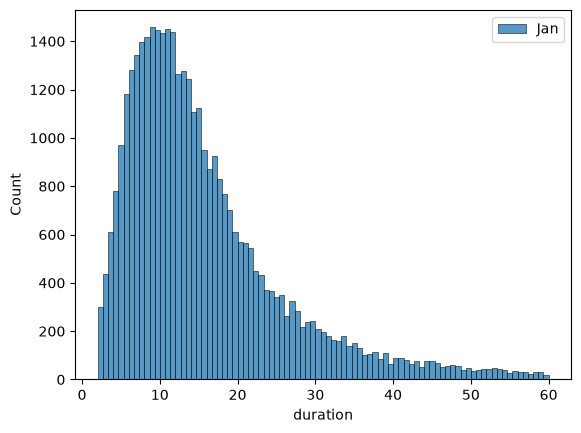

In [4]:
sns.histplot(jan_df["duration"], label="Jan")
plt.legend()

In [5]:
categorical_features = ["PULocationID", "DOLocationID"]
numerical_features = ["trip_distance"]

jan_df[categorical_features] = jan_df[categorical_features].astype(str)
feb_df[categorical_features] = feb_df[categorical_features].astype(str)

In [6]:
jan_df["PU_DO"] = jan_df["PULocationID"] + "_" + jan_df["DOLocationID"]
feb_df["PU_DO"] = feb_df["PULocationID"] + "_" + feb_df["DOLocationID"]

In [7]:
categorical_features = ["PU_DO", "PULocationID", "DOLocationID"]
numerical_features = ["trip_distance"]

dv = DictVectorizer()


train_dicts = (
    jan_df[categorical_features + numerical_features]
    .to_dict(orient="records")
)
X_train = dv.fit_transform(train_dicts)

val_dicts = (
    feb_df[categorical_features + numerical_features]
    .to_dict(orient="records")
)
X_val = dv.transform(val_dicts)

In [8]:
target = "duration"

y_train = jan_df[target]
y_val = feb_df[target]

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.045335116505339

In [10]:
lr = Ridge()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

6.97599230897637

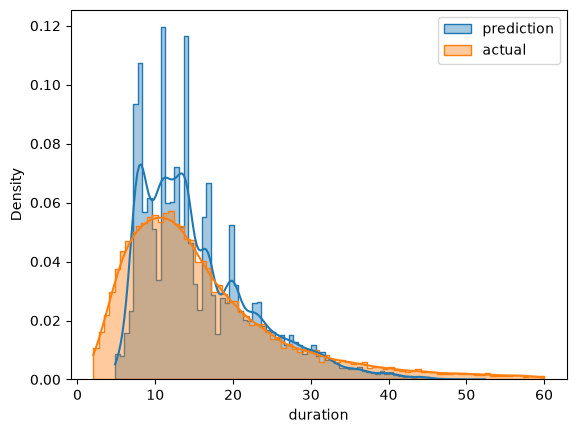

In [11]:
sns.histplot(
    y_pred,
    color="#1f77b4",
    label="prediction",
    kde=True,
    stat="density",
    alpha=0.4,
    element="step",
)

# 4. Plot the 'actual' distribution (Orange)
sns.histplot(
    y_val,
    color="#ff7f0e",
    label="actual",
    kde=True,
    stat="density",
    alpha=0.4,
    element="step",
)

plt.legend()
plt.show()

In [12]:
with open("./models/ridge.bin", "wb") as f:
    pickle.dump((dv, lr), f)